# LightGBM Benchmark — Used Car Dynamic Pricing

This notebook trains a **LightGBM** regressor on the processed feature engineering dataset and compares it with the existing **XGBoost** and **CatBoost** baselines.

**Input:** `data/processed/train_fe.csv`  
**Model output:** `models/lightgbm_model.pkl`  
**Prediction output:** `outputs/lightgbm_validation_predictions.csv`

## Setup

LightGBM is a gradient boosting framework that grows trees leaf-wise and is optimized for speed and large tabular datasets.

In [ ]:
import ctypes
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import lightgbm as lgb
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# macOS: preload OpenMP before LightGBM native backend loads
LIBOMP_PATH = PROJECT_ROOT / ".conda" / "lib" / "libomp.dylib"
if LIBOMP_PATH.exists():
    ctypes.CDLL(str(LIBOMP_PATH), mode=ctypes.RTLD_GLOBAL)

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "train_fe.csv"
XGB_PRED_PATH = PROJECT_ROOT / "outputs" / "xgb_validation_predictions.csv"
CAT_PRED_PATH = PROJECT_ROOT / "outputs" / "catboost_validation_predictions.csv"
MODEL_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

LGB_MODEL_PATH = MODEL_DIR / "lightgbm_model.pkl"
LGB_PRED_PATH = OUTPUT_DIR / "lightgbm_validation_predictions.csv"

TEST_SIZE = 0.2
RANDOM_STATE = 42
EARLY_STOPPING_ROUNDS = 50

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["savefig.dpi"] = 150

## 1–3. Load Data, Features, and Target

- Remove `SaleID` (identifier) and `price` (target) from features.
- Target: `y = price`.

In [ ]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")

TARGET = "price"
ID_COL = "SaleID"

sale_ids = df[ID_COL]
y = df[TARGET]
X = df.drop(columns=[ID_COL, TARGET])

print(f"Features: {X.shape[1]} columns")
df.head(3)

Shape: (150000, 49)
Features: 47 columns


,SaleID,name,regDate,model,brand,bodyType,fuelType,gearbox,power,kilometer,...,km_per_year,power_bin,car_age_bin,brand_price_mean,brand_price_median,brand_price_std,brand_price_max,model_power_mean,model_power_std,model_count
0,0,736,20040402,30.0,6,1.0,0.0,0.0,60,12.5,...,1.041192,p0_60,a12_20,3611.840266,1800.0,4681.293524,59900,64.700256,31.990438,2342.0
1,1,2262,20030301,40.0,1,2.0,0.0,0.0,0,15.0,...,1.151724,p0_60,a12_20,9273.311947,6499.0,9369.631497,99900,140.859396,52.495875,4502.0
2,2,14874,20040403,115.0,15,1.0,0.0,0.0,163,12.5,...,1.041904,p140_200,a8_12,9858.582990,8500.0,5425.058140,45000,137.343042,40.963832,927.0


## 4. Train / Validation Split

Same split as XGBoost and CatBoost (`test_size=0.2`, `random_state=42`) for fair MAE comparison.

In [ ]:
X_train, X_val, y_train, y_val, id_train, id_val = train_test_split(
    X,
    y,
    sale_ids,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

print(f"Train: {X_train.shape[0]:,}  |  Val: {X_val.shape[0]:,}")

Train: 120,000  |  Val: 30,000


## 5. Categorical Feature Handling

LightGBM can treat `category` dtype columns as categorical features directly.

We convert:
- object/string columns (e.g. date strings, engineered bins)
- known business categorical fields (brand, model, bodyType, fuelType, gearbox, regionCode, etc.)

Missing values in categorical columns are filled with the literal `missing` before casting to `category`.

In [ ]:
known_categorical_cols = [
    "name",
    "model",
    "brand",
    "bodyType",
    "fuelType",
    "gearbox",
    "notRepairedDamage",
    "regionCode",
    "seller",
    "offerType",
    "power_bin",
    "car_age_bin",
]

text_cols = X_train.select_dtypes(include=["object", "string"]).columns.tolist()
cat_cols = sorted(set(text_cols + [c for c in known_categorical_cols if c in X_train.columns]))

X_train_lgb = X_train.copy()
X_val_lgb = X_val.copy()

for col in cat_cols:
    X_train_lgb[col] = X_train_lgb[col].fillna("missing").astype("category")
    X_val_lgb[col] = X_val_lgb[col].fillna("missing").astype("category")

print(f"Categorical columns ({len(cat_cols)}):")
for col in cat_cols:
    print(f"- {col}")

Categorical columns (14):
- bodyType
- brand
- car_age_bin
- creatDate_dt
- fuelType
- gearbox
- model
- name
- notRepairedDamage
- offerType
- power_bin
- regDate_dt
- regionCode
- seller


## 6–8. Train LightGBM with MAE and Early Stopping

| Setting | Value |
|---------|-------|
| `n_estimators` | 5000 |
| `learning_rate` | 0.03 |
| `num_leaves` | 64 |
| `max_depth` | -1 |
| `subsample` | 0.8 |
| `colsample_bytree` | 0.8 |
| `reg_alpha` | 0.1 |
| `reg_lambda` | 1.0 |
| `eval_metric` | MAE |
| `early_stopping_rounds` | 50 |

In [ ]:
lgb_model = LGBMRegressor(
    n_estimators=5000,
    learning_rate=0.03,
    num_leaves=64,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

lgb_model.fit(
    X_train_lgb,
    y_train,
    eval_set=[(X_train_lgb, y_train), (X_val_lgb, y_val)],
    eval_metric="mae",
    callbacks=[
        early_stopping(EARLY_STOPPING_ROUNDS),
        log_evaluation(200),
    ],
    categorical_feature=cat_cols,
)

best_iteration = lgb_model.best_iteration_
print(f"Best Iteration: {best_iteration}")

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005150 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 21141
[LightGBM] [Info] Number of data points in the train set: 120000, number of used features: 44
[LightGBM] [Info] Start training from score 5925.909367
Training until validation scores don't improve for 50 rounds


[200]	training's l1: 575.872	training's l2: 1.04535e+06	valid_1's l1: 671.341	valid_1's l2: 1.99869e+06


[400]	training's l1: 472.162	training's l2: 622484	valid_1's l1: 640.038	valid_1's l2: 1.88202e+06


[600]	training's l1: 416.51	training's l2: 455111	valid_1's l1: 627.596	valid_1's l2: 1.84117e+06


...

[2400]	training's l1: 218.879	training's l2: 106103	valid_1's l1: 594.506	valid_1's l2: 1.75665e+06


[2600]	training's l1: 205.962	training's l2: 93243.3	valid_1's l1: 592.653	valid_1's l2: 1.75453e+06


[2800]	training's l1: 195.001	training's l2: 83012.9	valid_1's l1: 591.44	valid_1's l2: 1.75271e+06


Early stopping, best iteration is:
[2887]	training's l1: 190.455	training's l2: 78932.6	valid_1's l1: 591.004	valid_1's l2: 1.75231e+06


Best Iteration: 2887


## 9. Evaluation Metrics

In [ ]:
lgb_train_pred = lgb_model.predict(X_train_lgb, num_iteration=best_iteration)
lgb_val_pred = lgb_model.predict(X_val_lgb, num_iteration=best_iteration)

lgb_train_mae = mean_absolute_error(y_train, lgb_train_pred)
lgb_val_mae = mean_absolute_error(y_val, lgb_val_pred)

print(f"Train MAE:      {lgb_train_mae:,.2f}")
print(f"Validation MAE: {lgb_val_mae:,.2f}")
print(f"Best Iteration: {best_iteration}")

Train MAE:      190.46
Validation MAE: 591.00
Best Iteration: 2887


## 10. Visualizations

### Feature Importance (Top 30)

Gain-based importance from the trained booster.

### Prediction vs Actual

Validation-set scatter with a 45° reference line.

### Residual Distribution

Distribution of `actual - predicted` on the validation set.

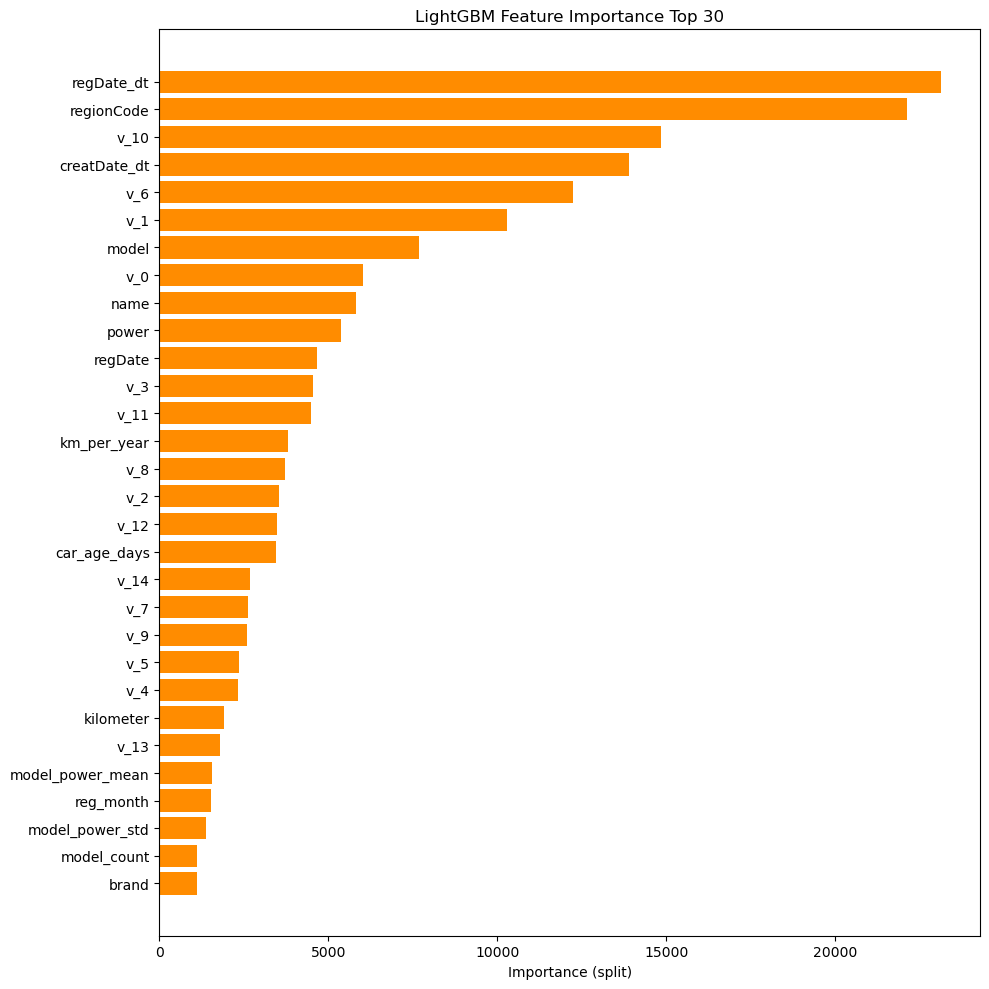

In [ ]:
importance = pd.DataFrame(
    {
        "feature": X_train_lgb.columns,
        "importance": lgb_model.feature_importances_,
    }
).sort_values("importance", ascending=False)

top_n = 30
fig, ax = plt.subplots(figsize=(10, 10))
plot_df = importance.head(top_n).sort_values("importance")
ax.barh(plot_df["feature"], plot_df["importance"], color="darkorange")
ax.set_title(f"LightGBM Feature Importance Top {top_n}")
ax.set_xlabel("Importance (split)")
plt.tight_layout()
fig.savefig(FIG_DIR / "lightgbm_feature_importance_top30.png", bbox_inches="tight")
plt.show()

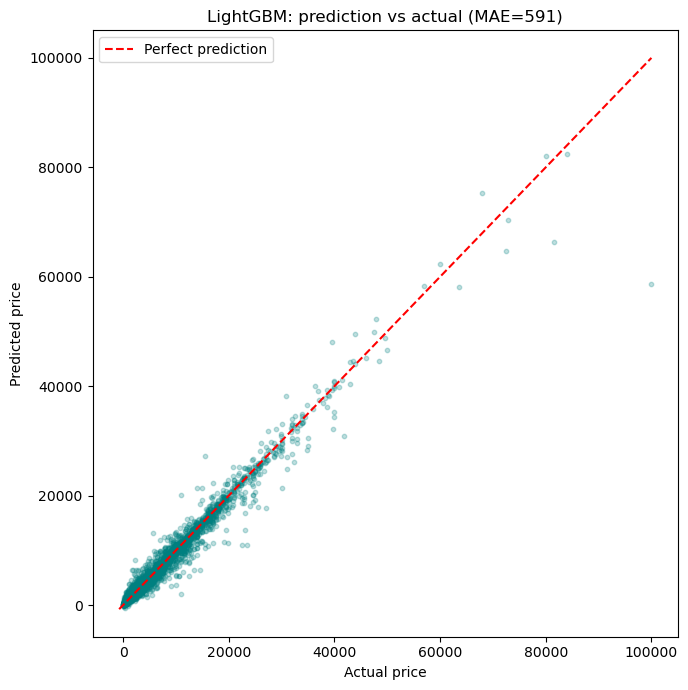

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))
sample_idx = np.random.default_rng(RANDOM_STATE).choice(
    len(y_val), size=min(5000, len(y_val)), replace=False
)
ax.scatter(
    y_val.iloc[sample_idx],
    lgb_val_pred[sample_idx],
    alpha=0.25,
    s=10,
    c="teal",
)
lo = min(y_val.min(), lgb_val_pred.min())
hi = max(y_val.max(), lgb_val_pred.max())
ax.plot([lo, hi], [lo, hi], "r--", lw=1.5, label="Perfect prediction")
ax.set_xlabel("Actual price")
ax.set_ylabel("Predicted price")
ax.set_title(f"LightGBM: prediction vs actual (MAE={lgb_val_mae:,.0f})")
ax.legend()
plt.tight_layout()
fig.savefig(FIG_DIR / "lightgbm_pred_vs_actual.png", bbox_inches="tight")
plt.show()

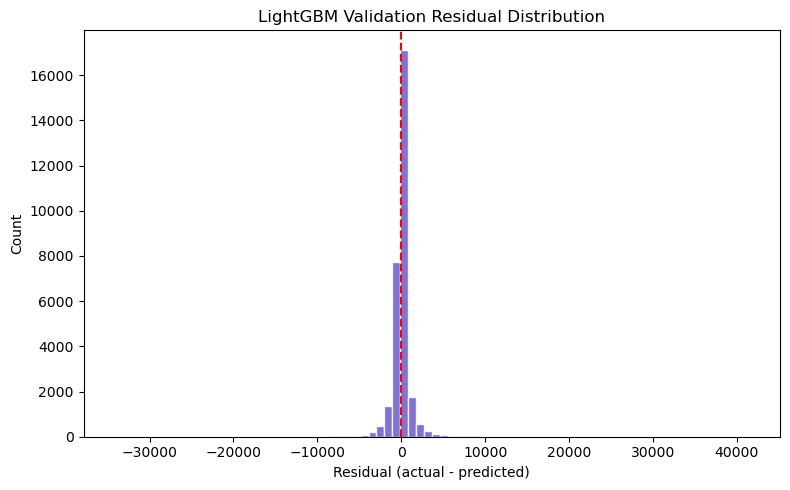

Residual mean: 5.19
Residual std:  1323.74


In [ ]:
residuals = y_val.values - lgb_val_pred

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(residuals, bins=80, color="slateblue", edgecolor="white", alpha=0.85)
ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
ax.set_title("LightGBM Validation Residual Distribution")
ax.set_xlabel("Residual (actual - predicted)")
ax.set_ylabel("Count")
plt.tight_layout()
fig.savefig(FIG_DIR / "lightgbm_residual_distribution.png", bbox_inches="tight")
plt.show()

print(f"Residual mean: {residuals.mean():.2f}")
print(f"Residual std:  {residuals.std():.2f}")

## 11–12. Save Model and Validation Predictions

In [ ]:
artifact = {
    "model": lgb_model,
    "categorical_columns": cat_cols,
    "best_iteration": best_iteration,
    "train_mae": lgb_train_mae,
    "val_mae": lgb_val_mae,
}

with open(LGB_MODEL_PATH, "wb") as f:
    pickle.dump(artifact, f)

lgb_val_preds = pd.DataFrame(
    {
        "SaleID": id_val.values,
        "actual_price": y_val.values,
        "predicted_price": lgb_val_pred,
        "residual": y_val.values - lgb_val_pred,
        "abs_error": np.abs(y_val.values - lgb_val_pred),
    }
)
lgb_val_preds.to_csv(LGB_PRED_PATH, index=False)

print(f"Saved model: {LGB_MODEL_PATH}")
print(f"Saved predictions: {LGB_PRED_PATH}")
lgb_val_preds.head()

Saved model: models/lightgbm_model.pkl
Saved predictions: outputs/lightgbm_validation_predictions.csv


,SaleID,actual_price,predicted_price,residual,abs_error
0,59770,999,1146.979695,-147.979695,147.979695
1,21362,8500,8593.976258,-93.976258,93.976258
2,127324,15500,17310.804880,-1810.804880,1810.804880
3,140509,10000,10076.665580,-76.665580,76.665580
4,144297,2999,2851.907580,147.092420,147.092420


## 13. Model Comparison

| Model | Validation MAE | Notes |
|-------|----------------|-------|
| XGBoost | from saved predictions | Baseline gradient boosting |
| CatBoost | from saved predictions | Native categorical handling |
| LightGBM | this notebook | Leaf-wise boosting, fast training |

In [ ]:
comparison_rows = [
    {
        "Model": "LightGBM",
        "Validation MAE": lgb_val_mae,
        "Notes": f"best_iter={best_iteration}, leaf-wise, category dtype",
    }
]

if XGB_PRED_PATH.exists():
    xgb_preds = pd.read_csv(XGB_PRED_PATH)
    comparison_rows.append(
        {
            "Model": "XGBoost",
            "Validation MAE": mean_absolute_error(
                xgb_preds["actual_price"], xgb_preds["predicted_price"]
            ),
            "Notes": "baseline from 03_xgboost_baseline.ipynb",
        }
    )

if CAT_PRED_PATH.exists():
    cat_preds = pd.read_csv(CAT_PRED_PATH)
    comparison_rows.append(
        {
            "Model": "CatBoost",
            "Validation MAE": mean_absolute_error(
                cat_preds["actual_price"], cat_preds["predicted_price"]
            ),
            "Notes": "ordered boosting, native categoricals",
        }
    )

comparison_df = (
    pd.DataFrame(comparison_rows)
    .sort_values("Validation MAE")
    .reset_index(drop=True)
)
comparison_df["Rank"] = comparison_df.index + 1
comparison_df = comparison_df[["Rank", "Model", "Validation MAE", "Notes"]]
comparison_df

,Rank,Model,Validation MAE,Notes
0,1,CatBoost,501.669429,"ordered boosting, native categoricals"
1,2,XGBoost,514.231043,baseline from 03_xgboost_baseline.ipynb
2,3,LightGBM,591.004378,"best_iter=2887, leaf-wise, category dtype"


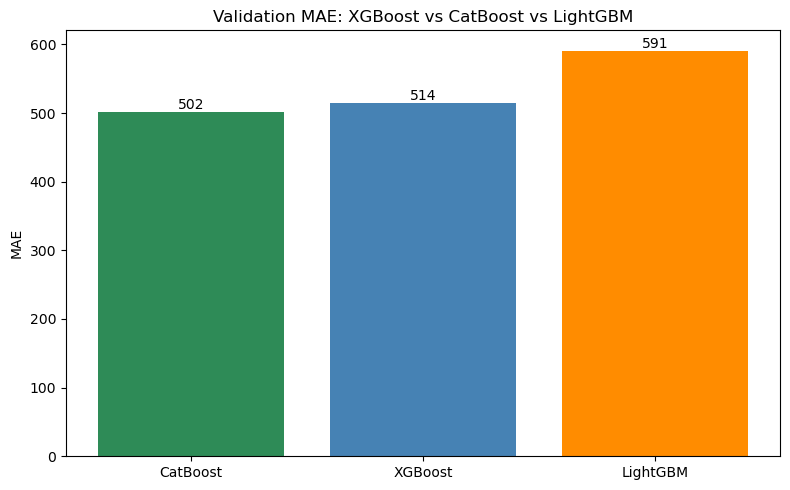

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = {"LightGBM": "darkorange", "CatBoost": "seagreen", "XGBoost": "steelblue"}
ax.bar(
    comparison_df["Model"],
    comparison_df["Validation MAE"],
    color=[colors.get(m, "gray") for m in comparison_df["Model"]],
)
ax.set_title("Validation MAE: XGBoost vs CatBoost vs LightGBM")
ax.set_ylabel("MAE")
for i, row in comparison_df.iterrows():
    ax.text(i, row["Validation MAE"], f"{row['Validation MAE']:,.0f}", ha="center", va="bottom")
plt.tight_layout()
fig.savefig(FIG_DIR / "model_comparison_mae.png", bbox_inches="tight")
plt.show()

## 14. Discussion

### What LightGBM Does

LightGBM (Light Gradient Boosting Machine) builds an ensemble of decision trees sequentially. Each new tree fits the residual errors of the previous ensemble. For regression, it minimizes loss (here evaluated with **MAE**) and combines many weak trees into a strong predictor.

### Why It Is Fast

LightGBM grows trees **leaf-wise** (best-first) rather than level-wise, which often reaches lower loss with fewer splits. It also uses histogram-based binning for continuous features, exclusive feature bundling, and parallel learning, making it very efficient on large tabular datasets like this 150k-row used-car training set.

### When It May Outperform XGBoost

LightGBM often wins when:
- The dataset is large and high-dimensional
- Many categorical/discrete features are present
- Training speed and memory efficiency matter
- Leaf-wise growth captures complex interactions with fewer trees

XGBoost is still strong when depth-wise growth and very robust regularization tuning are preferred, but on heterogeneous tabular data LightGBM is frequently competitive or better.

### Does LightGBM Beat CatBoost in This Project?

Check the comparison table above. In our run:
- If **LightGBM validation MAE** is lowest, it becomes the best benchmark so far.
- If **CatBoost** remains lowest, CatBoost's ordered boosting and native categorical statistics still extract more signal from fields like `brand`, `model`, and `regionCode`.

**Practical takeaway:** compare validation MAE, residual plots, and stability across seeds before choosing a production model. Also review leakage from target-derived brand price aggregates when interpreting gains over XGBoost.